In [102]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier

In [103]:
matches = pd.read_csv('../data/processed/features_v4.csv')

In [104]:
features = [ 'PPGDiff', 'GoalAgainstDiffLast5', 'ShotOTDiffLast5', 'GDPerGameDiff', 'GoalsAgainstPerGameDiff', 'EloDiff' ]

In [105]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [106]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [107]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

In [108]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [109]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)

print(model.classes_)

['A' 'D' 'H']


In [110]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.49473684210526314


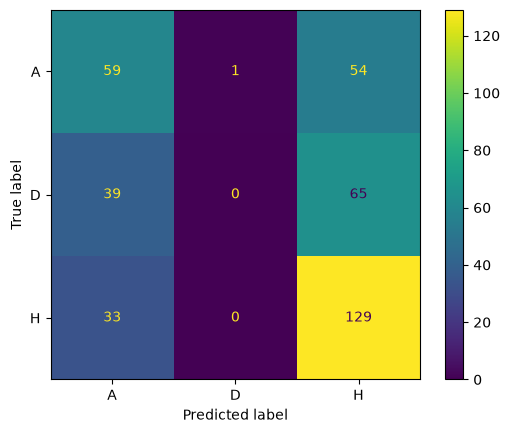

In [111]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [112]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.1715917 0.2135845 0.6148238]


In [113]:
results = test[['HomeTeam', 'AwayTeam', 'FTR']].copy() 
results['Predicted'] = preds 
results['AwayProb'] = probs[:, 0] 
results['DrawProb'] = probs[:, 1] 
results['HomeProb'] = probs[:, 2] 
results.head(10)

,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,Liverpool,Bournemouth,H,H,0.171592,0.213584,0.614824
1521,Aston Villa,Newcastle,D,H,0.298621,0.220320,0.481059
1522,Brighton,Fulham,D,H,0.225865,0.186155,0.587980
1523,Sunderland,West Ham,H,H,0.298283,0.243383,0.458334
1524,Tottenham,Burnley,H,H,0.212893,0.230583,0.556525
1525,Wolves,Man City,A,A,0.505698,0.206603,0.287699
1526,Chelsea,Crystal Palace,D,H,0.203391,0.233608,0.563001
1527,Nott'm Forest,Brentford,H,H,0.321587,0.206381,0.472032
1528,Man United,Arsenal,A,A,0.473304,0.218559,0.308137
1529,Leeds,Everton,H,A,0.516909,0.201200,0.281891


In [114]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

EloDiff                    0.287419
PPGDiff                    0.202826
GDPerGameDiff              0.188391
GoalsAgainstPerGameDiff    0.159913
ShotOTDiffLast5            0.099050
GoalAgainstDiffLast5       0.062402
dtype: float64


In [115]:
from sklearn.metrics import log_loss 
print(log_loss(y_test, probs))

1.0336212668001128


In [116]:
results['MaxProb'] = results[['AwayProb','DrawProb','HomeProb']].max(axis=1) 
results['Correct'] = results['Predicted'] == results['FTR'] 
bins = pd.cut(results['MaxProb'], [0.33,0.45,0.55,0.65,0.75,1.0]) 
results.groupby(bins)['Correct'].agg(['mean','count'])

,mean,count
MaxProb,,
"(0.33, 0.45]",0.468354,79
"(0.45, 0.55]",0.401515,132
"(0.55, 0.65]",0.548077,104
"(0.65, 0.75]",0.568182,44
"(0.75, 1.0]",0.761905,21
